# Portfolio Rebalancing

## Introduction

Suppose a portfolio manager has chosen a strategic asset allocation (SAA) for a client, but is yet to decide on an approach to tactical asset allocation (TAA).

A key component of tactical asset allocation is the rebalancing strategy and common approaches include:

*   *Periodic rebalancing:* for example, at the start of every calendar year, portfolio weights are returned to their SAA weights.
*   *Threshold rebalancing:* portfolio weights are returned to the SAA weights if they deviate from the SAA weights by a predetermined percentage.
*   *Dynamic rebalancing:* room is given for deviating from the SAA within a certain range to take advantage of short-term market views.

Rebalancing is important for diversification as if asset allocations are allowed to drift then the portfolio may become too concentrated.

In addition, without rebalancing, asset classes with higher returns in the short term may dominate the portfolio then mean-revert and lead the portfolio to experience large losses which could have been avoided.

However, rebalancing involves trading, which in turn incurs costs.

This project determines which of periodic or threshold rebalancing produces the greatest excess return relative to no rebalancing, net of fees, using randomly generated portfolios of US stocks.

Returns data will be gathered from 20 years of historical price data and Monte Carlo used to simulate returns and give mean statistics on how each of the rebalancing methods might have performed.

## Data Retrieval

FMP will be used to extract price data for analysis.

Below is a function which does so within Google Collab, which can be used with your own API key in the `.env.example` file provided with the project.

If you do not have an FMP API key, simply skip to the Analysis and Visualisation section, where the CSV file of the returns data is imported.

In [1]:
# Import all necessary packages for the project:

import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import userdata

In [2]:
# Function to get FMP data based on url, then specific parameter values related to that category:

def get_FMP_data(base_url, param_dict={}):

  # Base url before qualifiers and API key added:
  base_url = str(base_url)
  if base_url[-1] != '?':
    base_url += '?'

  # Checking parameters are in a dictionary:
  if type(param_dict) != dict:
    raise ValueError("2nd argument param_dict must be a dictionary.")

  # Adding parameters to the base url:
  for key, value in param_dict.items():
    base_url += str(key) + '=' + str(value) + '&'

  # Retrieve API key from Collab Secrets:
  api_key = userdata.get('FMP_API_KEY')

  if not api_key:
    raise ValueError("FMP_API_KEY environment variable is not set. Please ensure it's in your Secrets tab.")

  # Adding API key to base url:
  if base_url[-1] == '?':
    base_url = base_url[:-1]

  if base_url[-1] != '&':
    base_url += '&'

  base_url += 'apikey=' + api_key

  # Accessing FMP using url:
  response = requests.get(base_url, timeout=10)
  response.raise_for_status()
  data = response.json()

  if isinstance(data, dict) and "error" in data:
      print(f"FMP API error: {data['error']}")
      return pd.DataFrame()

  return pd.DataFrame(data)

To start, we will need a comprehensive ticker list of US stocks, to be randomly selected later as part of the portfolio generating process:

In [3]:
# Retrieving raw ticker data:
url = 'https://financialmodelingprep.com/stable/financial-statement-symbol-list'
params = {'reportingCurrency': 'USD'}
ticker_df = get_FMP_data(url, params)

# Filtering by USD as reporting currency:
ticker_df = ticker_df[ticker_df['reportingCurrency'] == 'USD']
print(ticker_df.head(10))

# Isolating ticker list:
ticker_list = ticker_df['symbol'].tolist()
print(f'{len(ticker_list)} tickers retrieved.')

    symbol                    companyName tradingCurrency reportingCurrency
2     DLOC        Digital Locations, Inc.             USD               USD
3     KAMN              Kaman Corporation             USD               USD
8     CTLP               Cantaloupe, Inc.             USD               USD
9     DION                  Dionics, Inc.             USD               USD
11  0KU1.L  Raymond James Financial, Inc.             USD               USD
12    RPDT                Rapidtron, Inc.             USD               USD
14     GVP              GSE Systems, Inc.             USD               USD
16    PCHM                PharmChem, Inc.             USD               USD
17   BKUTK                  Bank of Utica             USD               USD
19    FBIO         Fortress Biotech, Inc.             USD               USD
19334 tickers retrieved.


We will need a function that:

1.   Randomly selects 10 tickers from the ticker list,
2.   Retrieves 20 years of dividend-adjusted prices for the chosen stocks,
3.   Derives a return series from the price series.

The required function is coded below:


In [4]:
def random_tickers_df(num_tickers):
  returns_df = pd.DataFrame()
  valid_ticker_symbols = []
  tried_tickers = set() # Keep track of all tickers ever attempted in this call

  # Loop until we have num_tickers valid tickers or run out of unique tickers to try
  while len(valid_ticker_symbols) < num_tickers:

    available_tickers_for_selection = [t for t in ticker_list if t not in tried_tickers]

    if not available_tickers_for_selection:

        print(f"Warning: Ran out of unique tickers to try from the global list. Found only {len(valid_ticker_symbols)} valid tickers.")
        break # Exit if no more unique tickers to try

    # Select candidate tickers for this round. Try to pick enough to reach num_tickers, plus a buffer.
    num_to_select = min(num_tickers - len(valid_ticker_symbols) + 5, len(available_tickers_for_selection))

    if num_to_select <= 0: # Should not happen if available_tickers_for_selection is not empty

        break

    selected_for_round = np.random.choice(available_tickers_for_selection, size=num_to_select, replace=False)

    for ticker in selected_for_round:

      tried_tickers.add(ticker) # Mark this ticker as tried

      url = 'https://financialmodelingprep.com/stable/historical-price-eod/dividend-adjusted?'
      params = {'symbol': ticker, 'from': '2006-01-01','to': '2026-01-01'}
      price_df = get_FMP_data(url, params)

      # Using 'adjClose' based on FMP API documentation and previous observations.
      if not price_df.empty and 'adjClose' in price_df.columns:

        return_series = price_df['adjClose'].pct_change().dropna()

        if not return_series.empty and len(return_series) > 0: # Ensure there's actual data after dropping NA

            returns_df[ticker] = return_series
            valid_ticker_symbols.append(ticker)

            if len(valid_ticker_symbols) == num_tickers:

                break # We have enough valid tickers

        else:
            print(f"Skipping ticker {ticker} due to empty returns series after calculating returns.")

      else:
        print(f"Skipping ticker {ticker} due to no data or missing 'adjClose' column after API call.")

  # If we still don't have num_tickers, print a warning and return what we got
  if len(valid_ticker_symbols) < num_tickers:

      print(f"Warning: Only found {len(valid_ticker_symbols)} valid tickers out of requested {num_tickers}. Returning partial data.")

      # If returns_df is still empty at this point, we need to return an empty DataFrame
      if returns_df.empty:
          return pd.DataFrame()

      # Otherwise, trim returns_df to only include the valid_ticker_symbols found, sorted by symbol for consistency
      return returns_df[sorted(valid_ticker_symbols)]

  # If we successfully collected num_tickers, return the DataFrame with only these tickers, sorted by symbol
  return returns_df[sorted(valid_ticker_symbols)]

For simplicity, the search for tickers is confined to those who are currently trading and so look-ahead bias is unfortunately baked into the model.

As the investigation is comparative (rather than testing the performance of a strategy in absolute terms) the effects of this look-ahead bias should be mitigated.

More will be discussed in the final section on what the possible effects of including stocks which undergo backruptcy or mergers in the analysis might have been.

## Rebalancing Functions

The next step is to build functions which generate cumulative returns with or without rebalancing from initial weightings and the bootstrapped return series:

In [5]:
def returns_without_rebalancing(initial_weights, returns_df):

  # Initialising numpy arrays:
  initial_weights_vector = np.array(initial_weights)
  returns_array = np.array(returns_df)
  cumulative_returns_list = [initial_weights_vector] # Change to list
  percent_returns_list = []

  for r in range(returns_array.shape[0]):
    cumulative_returns_list.append(cumulative_returns_list[r] * (1 + returns_array[r]))
    percent_returns_list.append(returns_array[r])

  return np.array(cumulative_returns_list) # Convert to numpy array at the end

In [6]:
def returns_with_periodic_rebalancing(initial_weights, returns_df, period, cost_bps):

  # Initialising numpy arrays:
  initial_weights_vector = np.array(initial_weights)
  returns_array = np.array(returns_df)
  cumulative_returns_list = [initial_weights_vector] # Change to list

  for r in range(returns_array.shape[0]):

    # Rebalancing event:
    if r % period == 0:

      # Compute what portfolio should be with initial weightings:
      total_portfolio_value = cumulative_returns_list[r].sum()
      rebalanced_portfolio = initial_weights_vector * total_portfolio_value

      # Subtract costs:
      differential_vector = cumulative_returns_list[r] - rebalanced_portfolio
      cost_vector = np.abs(differential_vector) * cost_bps / 10000
      net_rebalanced_portfolio = rebalanced_portfolio - cost_vector

      # Returns step:
      cumulative_returns_list.append(net_rebalanced_portfolio * (1 + returns_array[r]))

    else:

      # Returns step only if no rebalancing required:
      cumulative_returns_list.append(cumulative_returns_list[r] * (1 + returns_array[r]))

  return np.array(cumulative_returns_list) # Convert to numpy array at the end

In [7]:
def returns_with_threshold_rebalancing(initial_weights, returns_df, threshold, cost_bps):

  # Initialising numpy arrays:
  initial_weights_vector = np.array(initial_weights)
  returns_array = np.array(returns_df)
  cumulative_returns_list = [initial_weights_vector] # Change to list

  for r in range(returns_array.shape[0]):

    # Compute what portfolio should be with initial weightings:
    total_portfolio_value = cumulative_returns_list[r].sum()
    rebalanced_portfolio = initial_weights_vector * total_portfolio_value

    # Work out current weightings before rebalancing:
    current_weights_vector = cumulative_returns_list[r] / total_portfolio_value
    net_rebalanced_portfolio = np.copy(cumulative_returns_list[r]) # Use np.copy to avoid modifying in place

    cost_vector = np.zeros_like(initial_weights_vector) # Initialize cost_vector with zeros

    for i in range(len(current_weights_vector)):

      differential = current_weights_vector[i] - initial_weights_vector[i]

      # Rebalance to target weights minus costs if stocks are over max threshold:
      if differential > threshold:

        cost_vector[i] = np.abs(differential) * cost_bps / 10000 # Correct cost calculation
        net_rebalanced_portfolio[i] = rebalanced_portfolio[i] - cost_vector[i]

      # Rebalance to target weights minus costs if stocks are under min threshold:
      elif differential < -threshold:

        cost_vector[i] = np.abs(differential) * cost_bps / 10000 # Correct cost calculation
        net_rebalanced_portfolio[i] = rebalanced_portfolio[i] - cost_vector[i]

      # No change to weights if within threshold:
      # else: # No need for explicit else as net_rebalanced_portfolio is already copied
        # cost_vector[i] = 0
        # net_rebalanced_portfolio[i] = cumulative_returns_list[r][i]

    # Returns step after rebalancing (whether required or not):
    cumulative_returns_list.append(net_rebalanced_portfolio * (1 + returns_array[r]))

  return np.array(cumulative_returns_list) # Convert to numpy array at the end

Now we are ready to:

1.   Generate a randomly weighted portfolio of 10 random stocks,
2.   Generate a return series of these stocks,
3. Generate the returns series of the portfolio:  
*   Without rebalancing,
*   With time rebalancing,
*   With threshold rebalancing,
4. Repeat the previous steps for 100 portfolios per rebalancing period, threshold and transactions cost.

Periodic rebalancing periods will range from P = 10 to P = 250 at intervals of 10, threshold rebalancing ranges from 1% to 20% at intervals of 1%, and transaction costs from 20 bps to 400 bps at intervals of 20 bps.




In [8]:
# Initialise data frame to hold returns for various strategies and transactions costs
# rebalancing_strategy_index = 0 for no rebalancing, 1 for periodic rebalancing, 2 for threshold rebalancing.
returns_df = pd.DataFrame(
    columns=[
        'rebalancing_strategy_index',
        'tickers',
        'weights',
        'rebalancing_period',
        'rebalancing_threshold',
        'transaction_costs',
        'portfolio_return',
        'return_over_no_rebalancing',
        'standard_deviation'
        ]
    )

# Generate 100 portfolios for each set of parameters:
for i in range(100):

  # Generate a random bootstrapped returns series of 10 random stocks, and 10 random weights:
  random_returns_array = random_tickers_df(10)

  # Check if enough valid tickers were returned. If not, skip this iteration.
  if random_returns_array.empty or random_returns_array.shape[1] < 10:
      print(f"Skipping iteration {i} due to insufficient valid tickers found (expected 10, got {random_returns_array.shape[1] if not random_returns_array.empty else 0}).")
      continue # Skip this iteration and try the next one

  random_weights = np.random.rand(10)
  random_weights = random_weights / random_weights.sum()

  # Generate portfolio returns with no rebalancing:
  no_rebalancing_returns_array = returns_without_rebalancing(random_weights, random_returns_array)
  total_portfolio_return_series = no_rebalancing_returns_array.sum(axis=1)
  portfolio_return_no_rebalancing = pd.Series(total_portfolio_return_series).pct_change(fill_method=None).dropna().mean()
  std_dev_no_rebalancing = pd.Series(total_portfolio_return_series).pct_change(fill_method=None).dropna().std()

  # Add return to returns data frame:
  returns_df_entry = [0, random_returns_array.columns.tolist(), random_weights.tolist(), 0, 0, 0, portfolio_return_no_rebalancing, 0, std_dev_no_rebalancing]
  returns_df.loc[len(returns_df)] = returns_df_entry

  for transaction_costs in range(20, 401, 20):

    # Generate portfolio returns with periodic rebalancing:
    for rebalancing_period in range(10, 251, 10):

      # Generate portfolio returns:
      periodic_rebalancing_returns_array = returns_with_periodic_rebalancing(random_weights, random_returns_array, rebalancing_period, transaction_costs)
      total_portfolio_return_series = periodic_rebalancing_returns_array.sum(axis=1)
      portfolio_return = pd.Series(total_portfolio_return_series).pct_change(fill_method=None).dropna().mean()
      std_dev = pd.Series(total_portfolio_return_series).pct_change(fill_method=None).dropna().std()

      # Add return to returns data frame:
      return_over_no_rebalancing = portfolio_return - portfolio_return_no_rebalancing
      returns_df_entry = [1, random_returns_array.columns.tolist(), random_weights.tolist(), rebalancing_period, 0, transaction_costs, portfolio_return, return_over_no_rebalancing, std_dev]
      returns_df.loc[len(returns_df)] = returns_df_entry

    # Generate portfolio returns with threshold rebalancing:
    for rebalancing_threshold in range(1, 21, 1):

      # Generate portfolio returns:
      threshold_rebalancing_returns_array = returns_with_threshold_rebalancing(random_weights, random_returns_array, rebalancing_threshold/100, transaction_costs)
      total_portfolio_return_series = threshold_rebalancing_returns_array.sum(axis=1)
      portfolio_return = pd.Series(total_portfolio_return_series).pct_change(fill_method=None).dropna().mean()
      std_dev = pd.Series(total_portfolio_return_series).pct_change(fill_method=None).dropna().std()

      # Add return to returns data frame:
      return_over_no_rebalancing = portfolio_return - portfolio_return_no_rebalancing
      returns_df_entry = [2, random_returns_array.columns.tolist(), random_weights.tolist(), 0, rebalancing_threshold/100, transaction_costs, portfolio_return, return_over_no_rebalancing, std_dev]
      returns_df.loc[len(returns_df)] = returns_df_entry

# Save returns_df as a .csv (as it takes a while to generate):
returns_df.to_csv('returns_df.csv')

# View results:
print(returns_df)

Skipping ticker FACA-UN due to no data or missing 'adjClose' column after API call.
Skipping ticker XLRM due to empty returns series after calculating returns.
Skipping ticker AVTR-PA due to empty returns series after calculating returns.
Skipping ticker FCAX-UN due to no data or missing 'adjClose' column after API call.
Skipping ticker 0UAI.L due to no data or missing 'adjClose' column after API call.
Skipping ticker EXDI due to empty returns series after calculating returns.
Skipping ticker NRZ-PA due to no data or missing 'adjClose' column after API call.
Skipping ticker ELSLF due to no data or missing 'adjClose' column after API call.
Skipping ticker FCAX-UN due to no data or missing 'adjClose' column after API call.
Skipping ticker VENV due to empty returns series after calculating returns.
Skipping ticker JZCZ.L due to no data or missing 'adjClose' column after API call.
Skipping ticker BRMK-WT due to no data or missing 'adjClose' column after API call.
Skipping ticker AVHOQ due 

## Analysis and Visualisation

Let's perform a cursory check on the portfolio returns distribution for plotting:

In [9]:
# Import the .csv file from the previous step:
returns_df = pd.read_csv('returns_df.csv')

# Cursory check on returrns distribution:
returns_df['portfolio_return'].describe()

,portfolio_return
count,90100.000000
mean,4.360405
std,58.593427
min,-0.010714
25%,0.002177
50%,0.009028
75%,0.093096
max,1186.361214


Clearly there are high outliers in the returns data which will render any plots unmanageable, so let's remove these:

In [10]:
# Compute upper and lower quartiles and interquartile range:
q1 = returns_df['portfolio_return'].describe()['25%']
q3 = returns_df['portfolio_return'].describe()['75%']
iqr = q3 - q1

# Exclude any values more than 1.5 * iqr away from upper or lower quartiles:
high_cutoff = q3 + 1.5 * iqr
low_cutoff = q1 - 1.5 * iqr
returns_df_no_outliers = returns_df[(returns_df['portfolio_return'] < high_cutoff) & (returns_df['portfolio_return'] > low_cutoff)]

# Check new distribution:
returns_df_no_outliers['portfolio_return'].describe()

,portfolio_return
count,72672.000000
mean,0.022476
std,0.039509
min,-0.010714
25%,0.001485
50%,0.005414
75%,0.023088
max,0.229197


Now we have computed all the necessary portfolio returns, let's examine the results with some visualisations.

First, let's examine box plots of returns from periodic rebalancing at different time periods:

/tmp/ipykernel_156/3683154624.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  returns_df_no_outliers['rebalancing_period'] = returns_df_no_outliers['rebalancing_period'].astype(int)


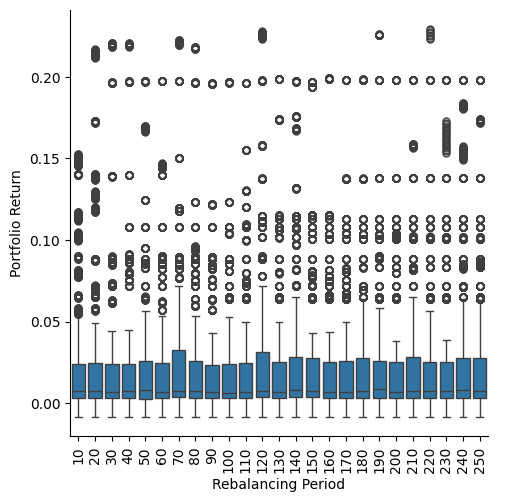

In [11]:
# Change rebalancing_period to int:
returns_df_no_outliers['rebalancing_period'] = returns_df_no_outliers['rebalancing_period'].astype(int)

# Category plot of returns for various rebalancing periods, with hue as transaction costs:
c = sns.catplot(

    # Filter data for periodic rebalancing strategy:
    data=returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 1],
    x='rebalancing_period',
    y='portfolio_return',
    kind='box'
    )

c.set_axis_labels("Rebalancing Period", "Portfolio Return")
c.set_xticklabels(rotation=90)
plt.show()

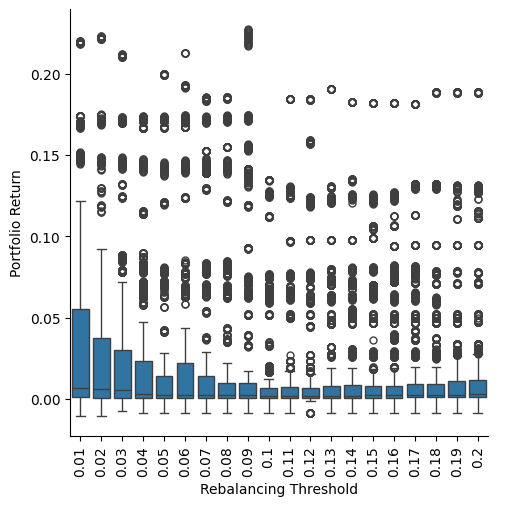

In [12]:
# Category plot of returns for various thresholds, with hue as transaction costs:
c = sns.catplot(

    # Filter data for threshold rebalancing strategy:
    data=returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 2],
    x='rebalancing_threshold',
    y='portfolio_return',
    kind='box',
    )

c.set_axis_labels("Rebalancing Threshold", "Portfolio Return")
c.set_xticklabels(rotation=90)
plt.show()

We can also produce a 3D surface showing how excess returns for each strategy over no rebalancing varies with the rebalancing period/threshold and transactions costs.

For this, we will use only mean excess returns per rebalancing period/threshold and per transactions cost.

The code below populates a new data frame with this information:

In [20]:
# New grouped data frame for periodic rebalancing:
periodic_mean_excess_returns_df = returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 1]
periodic_mean_excess_returns_df = periodic_mean_excess_returns_df.drop(
    columns=['rebalancing_strategy_index', 'tickers', 'weights', 'rebalancing_threshold', 'portfolio_return']
    )
periodic_mean_excess_returns_df = periodic_mean_excess_returns_df.groupby(
    ['rebalancing_period', 'transaction_costs']
    ).median()

# New grouped data frame for threshold rebalancing:
threshold_mean_excess_returns_df = returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 2]
threshold_mean_excess_returns_df = threshold_mean_excess_returns_df.drop(
    columns=['rebalancing_strategy_index', 'tickers', 'weights', 'rebalancing_period', 'portfolio_return']
    )
threshold_mean_excess_returns_df = threshold_mean_excess_returns_df.groupby(
    ['rebalancing_threshold', 'transaction_costs']
    ).median()

Below are the plots of the 3D surfaces:

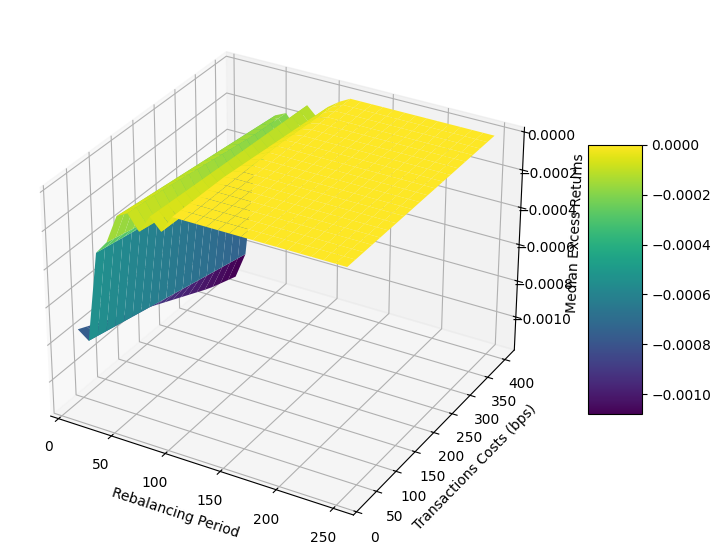

In [21]:
# Reset index to turn the MultiIndex into columns for easier pivoting
plot_df = periodic_mean_excess_returns_df.reset_index()

# Pivot the DataFrame using the actual column names
pivot_df = plot_df.pivot(index='transaction_costs', columns='rebalancing_period', values='return_over_no_rebalancing')

# Create grid arrays from the pivot:
X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values

# Plot:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('Transactions Costs (bps)')
ax.set_zlabel('Median Excess Returns')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

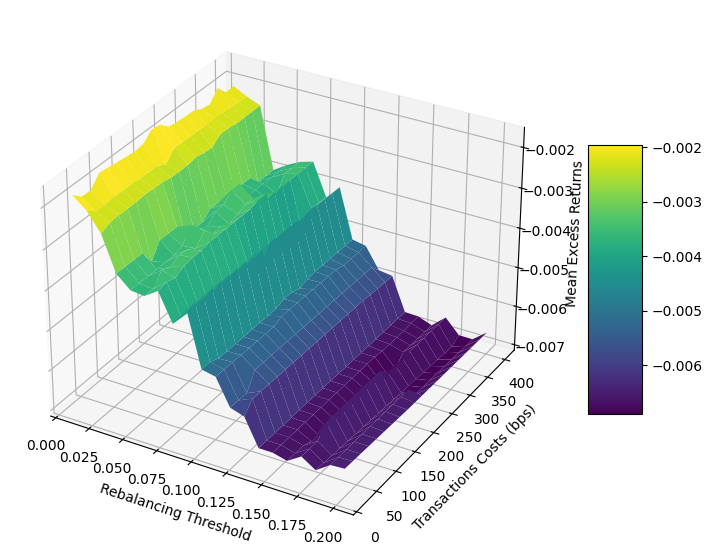

In [22]:
# Reset index to turn the MultiIndex into columns for easier pivoting
plot_df = threshold_mean_excess_returns_df.reset_index()

# Pivot the DataFrame using the actual column names
pivot_df = plot_df.pivot(index='transaction_costs', columns='rebalancing_threshold', values='return_over_no_rebalancing')

# Create grid arrays from the pivot:
X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values

# Plot:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('Rebalancing Threshold')
ax.set_ylabel('Transactions Costs (bps)')
ax.set_zlabel('Mean Excess Returns')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

The plots above are suprising. From the box plots, the period used for periodic rebalancing clearly has no discernible effect on portfolio return and from the 3D surface plots, clearly both strategies perform worse than without any rebalancing.

Perhaps even more surpising is the effect of transactions costs: the surface plots suggest little effect on any of the excess returns.

To dig further into this, let us produce a correlation matrix between the factors and surface plots of absolute return (rather than excess return):

In [16]:
# Spearman's rank correlation matrix of factors:
returns_df_no_outliers.corr(method='spearman', numeric_only=True)

,Unnamed: 0,rebalancing_strategy_index,rebalancing_period,rebalancing_threshold,transaction_costs,portfolio_return,return_over_no_rebalancing,standard_deviation
Unnamed: 0,1.000000,0.020792,-0.018714,0.017455,0.011831,0.052019,-0.019907,-0.011012
rebalancing_strategy_index,0.020792,1.000000,-0.890130,0.948904,0.003940,-0.250340,-0.383449,-0.025238
rebalancing_period,-0.018714,-0.890130,1.000000,-0.848204,0.002229,0.229268,0.392754,0.037784
rebalancing_threshold,0.017455,0.948904,-0.848204,1.000000,0.001564,-0.254015,-0.410429,-0.029269
transaction_costs,0.011831,0.003940,0.002229,0.001564,1.000000,-0.006565,-0.010353,-0.001279
portfolio_return,0.052019,-0.250340,0.229268,-0.254015,-0.006565,1.000000,0.084691,0.881851
return_over_no_rebalancing,-0.019907,-0.383449,0.392754,-0.410429,-0.010353,0.084691,1.000000,-0.019677
standard_deviation,-0.011012,-0.025238,0.037784,-0.029269,-0.001279,0.881851,-0.019677,1.000000


In [23]:
# New grouped data frame for periodic rebalancing:
periodic_mean_returns_df = returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 1]
periodic_mean_returns_df = periodic_mean_returns_df.drop(
    columns=['rebalancing_strategy_index', 'tickers', 'weights', 'rebalancing_threshold', 'return_over_no_rebalancing']
    )
periodic_mean_returns_df = periodic_mean_returns_df.groupby(
    ['rebalancing_period', 'transaction_costs']
    ).median()

# New grouped data frame for threshold rebalancing:
threshold_mean_returns_df = returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 2]
threshold_mean_returns_df = threshold_mean_returns_df.drop(
    columns=['rebalancing_strategy_index', 'tickers', 'weights', 'rebalancing_period', 'return_over_no_rebalancing']
    )
threshold_mean_returns_df = threshold_mean_returns_df.groupby(
    ['rebalancing_threshold', 'transaction_costs']
    ).median()

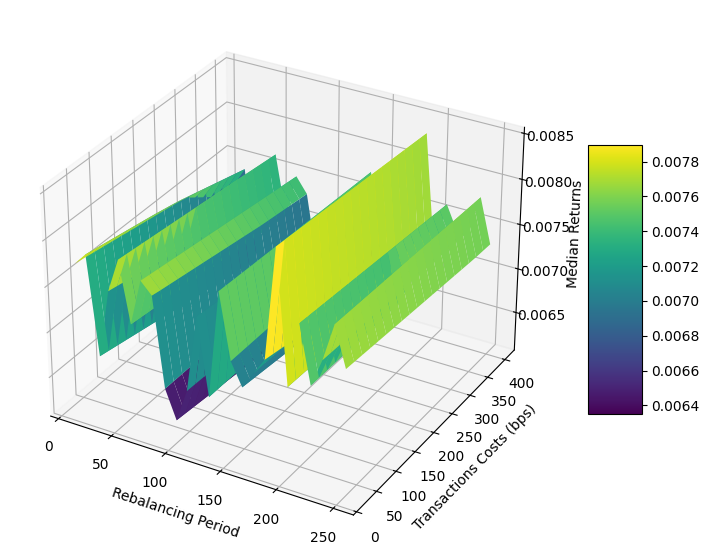

In [24]:
# Reset index to turn the MultiIndex into columns for easier pivoting
plot_df = periodic_mean_returns_df.reset_index()

# Pivot the DataFrame using the actual column names
pivot_df = plot_df.pivot(index='transaction_costs', columns='rebalancing_period', values='portfolio_return')

# Create grid arrays from the pivot:
X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values

# Plot:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('Transactions Costs (bps)')
ax.set_zlabel('Median Returns')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

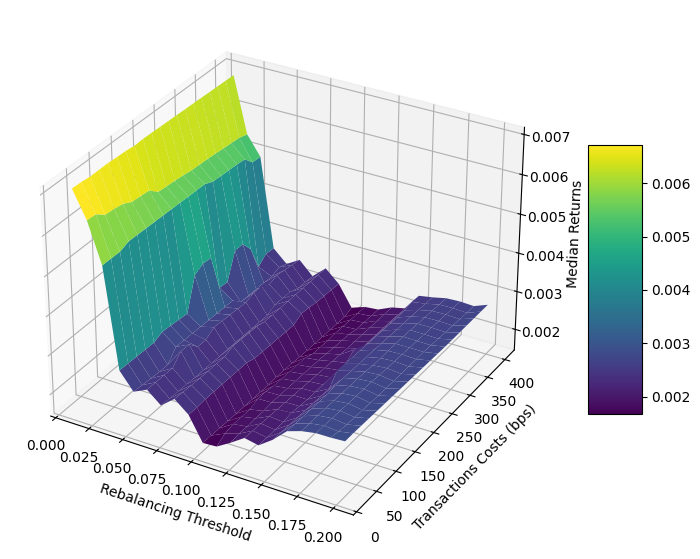

In [26]:
# Reset index to turn the MultiIndex into columns for easier pivoting
plot_df = threshold_mean_returns_df.reset_index()

# Pivot the DataFrame using the actual column names
pivot_df = plot_df.pivot(index='transaction_costs', columns='rebalancing_threshold', values='portfolio_return')

# Create grid arrays from the pivot:
X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values

# Plot:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('Rebalancing Threshold')
ax.set_ylabel('Transactions Costs (bps)')
ax.set_zlabel('Median Returns')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

Transactions costs have close to zero correlation with the rebalancing period, rebalancing threshold, portfolio return and excess return over no rebalancing.

Transactions costs always negatively affect portfolio returns, so it is especially surprising to see the correlations between transactions costs and the rebalancing period and threshold as slightly positive.

That transactions costs had little affect on any returns strategies is confirmed by the plots of absolute return, where the changes with respect to transactions costs are relatively flat as well.

It is possible that the rebalancing processes in this study affected poorly performing stocks the most, and since transactions costs were modelled on a proportional (rather than absolute) basis, a position of low value will incur low transactions costs when rebalancced.

Overall, the surprising conclusion from this limited study is that any rebalancing strategy has negative alpha.

Howevever, rebalancing also may improve risk-adjusted returns.

Taking the risk-free rate to be the 20-year US treasury par rate of 4.62% on 3rd January 2006 (at the start of the returns period), let's add another column to the data frame for the Sharpe ratio:

In [27]:
# Daily risk free rate from annualised rate:
daily_risk_free_rate = 0.0462 / 252

# Add a column to the data frame for the Sharpe ratio:
returns_df_no_outliers['sharpe_ratio'] = (returns_df_no_outliers['portfolio_return'] - daily_risk_free_rate) / returns_df_no_outliers['standard_deviation']

/tmp/ipykernel_156/1979014744.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  returns_df_no_outliers['sharpe_ratio'] = (returns_df_no_outliers['portfolio_return'] - daily_risk_free_rate) / returns_df_no_outliers['standard_deviation']


Now let's produce surface plots of the Sharpe ratio for each rebalancing strategy:

In [29]:
# The steps to isolate columns and take medians need to be redone.
# New grouped data frame for periodic rebalancing:
periodic_mean_returns_df = returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 1]
periodic_mean_returns_df = periodic_mean_returns_df.drop(
    columns=['rebalancing_strategy_index', 'tickers', 'weights', 'rebalancing_threshold', 'return_over_no_rebalancing']
    )
periodic_mean_returns_df = periodic_mean_returns_df.groupby(
    ['rebalancing_period', 'transaction_costs']
    ).median()

# New grouped data frame for threshold rebalancing:
threshold_mean_returns_df = returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 2]
threshold_mean_returns_df = threshold_mean_returns_df.drop(
    columns=['rebalancing_strategy_index', 'tickers', 'weights', 'rebalancing_period', 'return_over_no_rebalancing']
    )
threshold_mean_returns_df = threshold_mean_returns_df.groupby(
    ['rebalancing_threshold', 'transaction_costs']
    ).median()

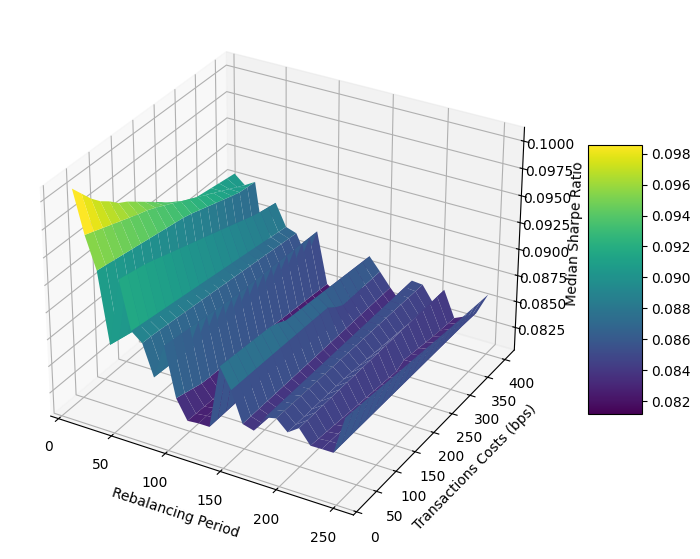

In [30]:
# Reset index to turn the MultiIndex into columns for easier pivoting
plot_df = periodic_mean_returns_df.reset_index()

# Pivot the DataFrame using the actual column names
pivot_df = plot_df.pivot(index='transaction_costs', columns='rebalancing_period', values='sharpe_ratio')

# Create grid arrays from the pivot:
X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values

# Plot:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('Transactions Costs (bps)')
ax.set_zlabel('Median Sharpe Ratio')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

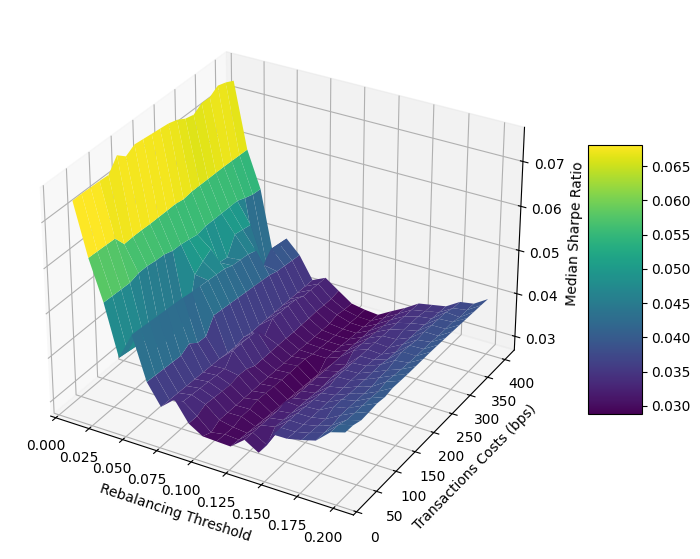

In [31]:
# Reset index to turn the MultiIndex into columns for easier pivoting
plot_df = threshold_mean_returns_df.reset_index()

# Pivot the DataFrame using the actual column names
pivot_df = plot_df.pivot(index='transaction_costs', columns='rebalancing_threshold', values='sharpe_ratio')

# Create grid arrays from the pivot:
X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values

# Plot:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('Rebalancing Threshold')
ax.set_ylabel('Transactions Costs (bps)')
ax.set_zlabel('Median Sharpe Ratio')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

For comparison, we will need the median Sharpe ratio with no rebalancing:

In [33]:
sr_no_rebalancing = returns_df_no_outliers[returns_df_no_outliers['rebalancing_strategy_index'] == 0]['sharpe_ratio'].median()
print(f'Median Sharpe ratio with no rebalancing = {sr_no_rebalancing}')

Median Sharpe ratio with no rebalancing = 0.08768506576317961


From examining the surface plots, the median Sharpe ratio with no rebalancing is only exceeded for periodic rebalancing at the most frequent periods (daily to weekly) and with minimal transactions costs. For every other choice of parameters and strategy, the method does not outperform no rebalancing on a risk-adjusted basis.

## Conclusion

The conclusions of this study are surprising: that both periodic and threshold rebalancing underperform no rebalancing "on average" and both on an absolute and risk-adjusted basis.

However, the methods used have obvious drawbacks which could be addressed in further work:

1.   Lookahead and survivorship biases are baked into the data and a futher study could investigate the impact of delistings, adjusting for private buyouts, M&A activity and bankruptcies.
2.   Transactions costs were modelled as proportional: a fixed component could be introduced to model real-life transactions costs more accurately.
3. The period 2006-2026 from which the data is gathered crosses several economic regimes: focussing on a single regime may have produced different conclusions.
4. The same code could be tested on bootstrapped returns: this has the advantage of modelling hypothetical regimes with the same average return and risk profiles, but evens out natural volatility clustering which could impact the rebalancing strategies.

## References

CFA Institute (2026) "Asset Allocation: CFA Program Curriculum, 2026 Level III Core, Volume 1". For candidate use only. Not for distribution.

U.S. Department of the Treasury (2024) "Daily Treasury Rate Archives" Available at: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives (Accessed 6 March 2026)